In [111]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns',100)

In [112]:
df = pd.read_csv("training_data.csv")

In [113]:
df.head()

,Unnamed: 0,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,0,259912530,88114716,Caucasian,Female,[60-70),?,1,6,7,1,MC,?,34,0,10,6,0,0,490,427,571,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
1,1,37094196,604017,Caucasian,Female,[60-70),?,1,1,7,2,?,Family/GeneralPractice,39,0,11,0,0,0,428,250,305,4,NaN,NaN,Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes,NO
2,2,69819834,3401055,AfricanAmerican,Female,[40-50),?,1,6,7,5,?,Family/GeneralPractice,63,1,11,1,0,11,535,285,585,5,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30
3,3,234245010,71780013,Caucasian,Male,[70-80),?,2,6,1,2,MC,?,39,0,22,3,0,2,482,428,585,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes,NO
4,4,160693860,82716489,Caucasian,Female,[80-90),?,6,3,7,12,?,InternalMedicine,71,1,15,0,0,0,733,584,682,6,Norm,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,>30


In [114]:
features = ["time_in_hospital", "num_lab_procedures", "num_procedures", "num_medications", "number_outpatient", "number_emergency", "number_inpatient"]

quantitative_features = df[features]

In [115]:
quantitative_features.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient
0,1,34,0,10,6,0,0
1,2,39,0,11,0,0,0
2,5,63,1,11,1,0,11
3,2,39,0,22,3,0,2
4,12,71,1,15,0,0,0


In [116]:
#encode <30 as 0, >30 as 1, and No as 2
target  = df.loc[:, "readmitted"]

enc = OrdinalEncoder()
enc.fit(target.to_frame())

target = enc.transform(target.to_frame())


In [117]:
quantitative_features.insert(quantitative_features.shape[1], "Readmitted", target)
quantitative_features.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,Readmitted
0,1,34,0,10,6,0,0,2.0
1,2,39,0,11,0,0,0,2.0
2,5,63,1,11,1,0,11,1.0
3,2,39,0,22,3,0,2,2.0
4,12,71,1,15,0,0,0,1.0


In [118]:
corr = quantitative_features.corr()

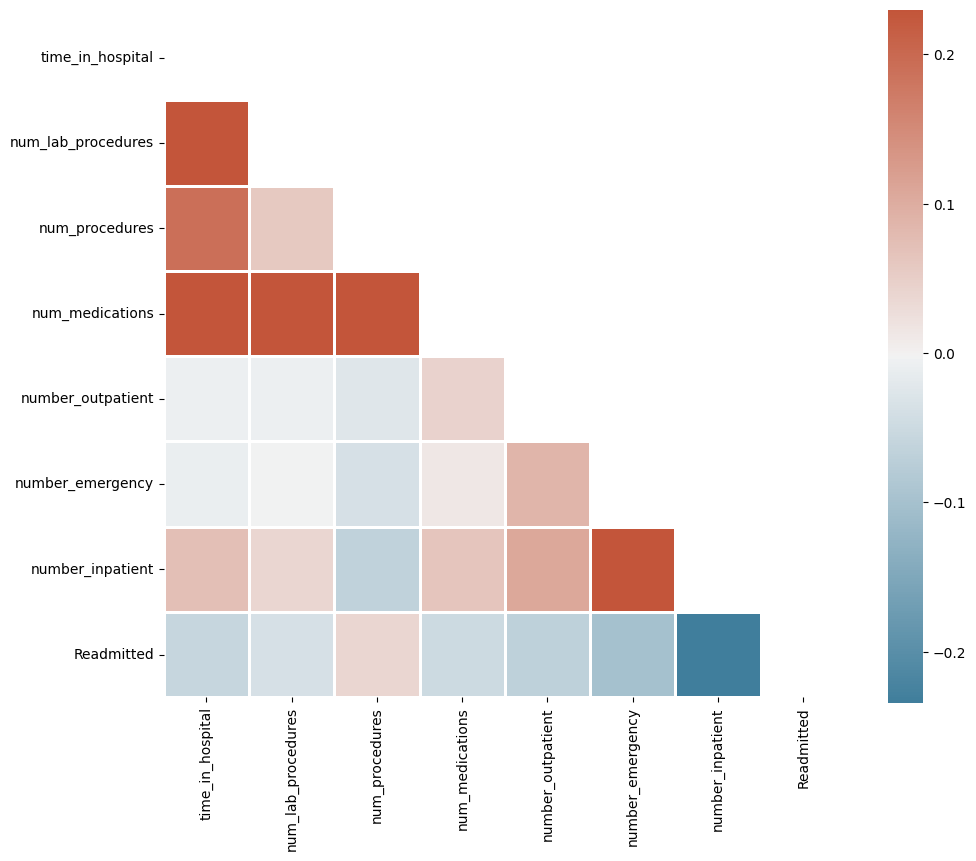

In [119]:
mask = np.triu(np.ones_like(corr, dtype=bool))

f, axis = plt.subplots(figsize = (11,9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask = mask, cmap=cmap, square = True, linewidths=2, vmax=.23);

In [120]:
med_order = ['No', 'Down', 'Steady', 'Up']
binary_order = ['No', 'Steady']
glu_order = ['Norm', '>200', '>300']
a1c_order = ['Norm', '>7', '>8']
change_order = ['No', 'Ch']
diabetesMed_order = ["No", "Yes"]
age_order = ['[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)','[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)']

In [121]:
ordinal_features = ['age', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
df_ordinal = df[ordinal_features]

df_ordinal.head()

,age,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,[60-70),No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes
1,[60-70),Steady,No,No,No,No,No,Up,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Ch,Yes
2,[40-50),No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No
3,[70-80),No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Down,No,No,No,No,No,Ch,Yes
4,[80-90),No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No


In [122]:
med_categories = [med_order for i in range(21)]
categories = [age_order] + med_categories + [change_order] + [diabetesMed_order]
ord_enc = OrdinalEncoder(
    categories = categories
)

df_ordinal = ord_enc.fit_transform(df_ordinal)

for i in range(len(ordinal_features)):
    quantitative_features.insert(quantitative_features.shape[1]-1, ordinal_features[i], df_ordinal[:, i])

quantitative_features.head()

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,age,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,Readmitted
0,1,34,0,10,6,0,0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
1,2,39,0,11,0,0,0,6.0,2.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
2,5,63,1,11,1,0,11,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2,39,0,22,3,0,2,7.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,2.0
4,12,71,1,15,0,0,0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


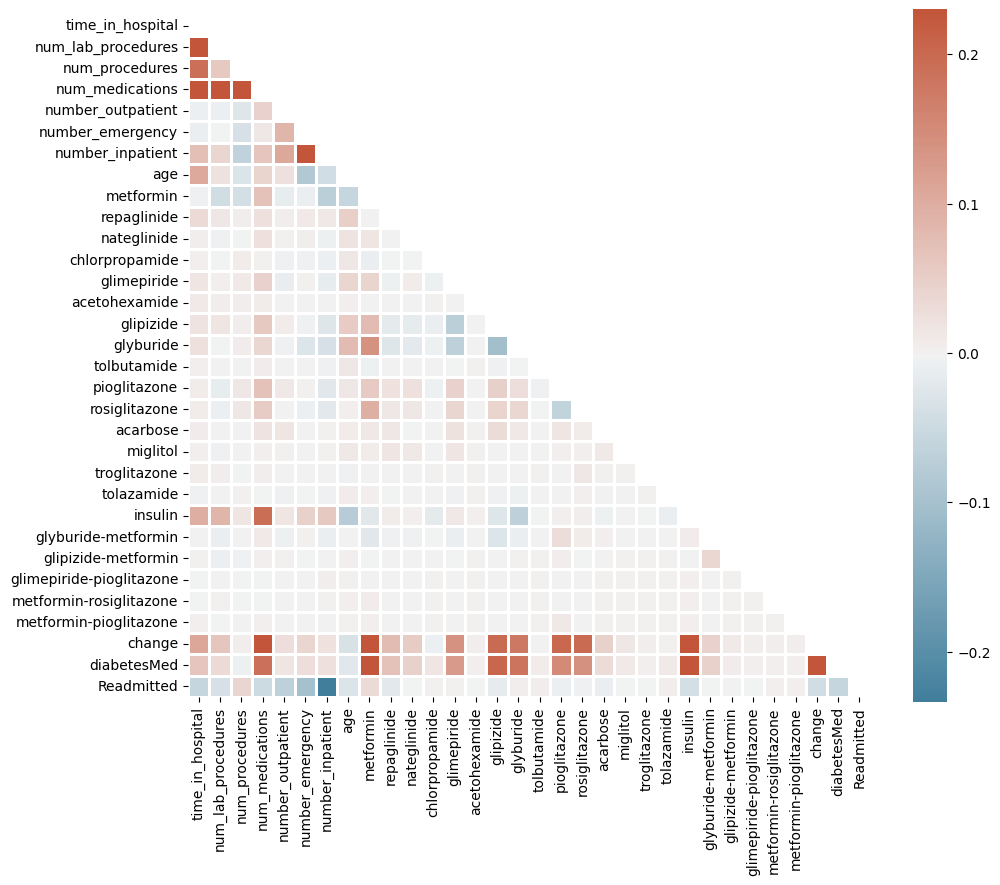

In [123]:
corr = quantitative_features.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

f, axis = plt.subplots(figsize = (11,9))

cmap = sns.diverging_palette(230, 20, as_cmap=True)

sns.heatmap(corr, mask = mask, cmap=cmap, square = True, linewidths=2, vmax=.23);